In [1]:
# Import all packages needed
import warnings
import pandas as pd
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

%matplotlib inline

# Update 2026-07-15: imports for model tuning and feature importance
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

In [2]:
# To suppress FutureWarnings for cleaner look
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Import churn csv; csv is 'clean', but we will do a bit of extra cleaning/wrangling here for any issues missed in initial cleaning.
global df
df = pd.read_csv('./churn_clean.csv', keep_default_na=False)
pd.set_option('display.max_columns', None)
df.head(5)

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Contract,Port_modem,Tablet,InternetService,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,38,Urban,America/Sitka,Environmental health practitioner,0,68,28561.99,Widowed,Male,No,7.978323,10,0,1,No,One year,Yes,Yes,Fiber Optic,Yes,No,Yes,Yes,No,No,No,Yes,Yes,Credit Card (automatic),6.795513,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,10446,Urban,America/Detroit,"Programmer, multimedia",1,27,21704.77,Married,Female,Yes,11.699080,12,0,1,Yes,Month-to-month,No,Yes,Fiber Optic,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Bank Transfer(automatic),1.156681,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,3735,Urban,America/Los_Angeles,Chief Financial Officer,4,50,9609.57,Widowed,Female,No,10.752800,9,0,1,Yes,Two Year,Yes,No,DSL,Yes,Yes,No,No,No,No,No,Yes,Yes,Credit Card (automatic),15.754144,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,13863,Suburban,America/Los_Angeles,Solicitor,1,48,18925.23,Married,Male,No,14.913540,15,2,0,Yes,Two Year,No,No,DSL,Yes,No,Yes,No,No,No,Yes,No,Yes,Mailed Check,17.087227,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,11352,Suburban,America/Chicago,Medical illustrator,0,83,40074.19,Separated,Male,Yes,8.147417,16,2,1,No,Month-to-month,Yes,No,Fiber Optic,No,No,No,No,No,Yes,Yes,No,No,Mailed Check,1.670972,149.948316,271.493436,4,4,4,3,4,4,4,5


In [4]:
# Quick overview of full DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [5]:
# Check for duplicates
print(df.duplicated().value_counts())

False    10000
Name: count, dtype: int64


In [6]:
# Check for null values
null_df = df.isnull().sum()
df.isna().sum()
print(null_df)

CaseOrder               0
Customer_id             0
Interaction             0
UID                     0
City                    0
State                   0
County                  0
Zip                     0
Lat                     0
Lng                     0
Population              0
Area                    0
TimeZone                0
Job                     0
Children                0
Age                     0
Income                  0
Marital                 0
Gender                  0
Churn                   0
Outage_sec_perweek      0
Email                   0
Contacts                0
Yearly_equip_failure    0
Techie                  0
Contract                0
Port_modem              0
Tablet                  0
InternetService         0
Phone                   0
Multiple                0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
PaperlessBilling        0
PaymentMetho

In [7]:
# Change Zip to string so we can front fill zeroes and keep zip codes accurate to the original file
df['Zip'] = df['Zip'].astype(str)
df['Zip'] = df['Zip'].str.zfill(5)
df['Zip'].loc[df['Zip'].str.len() == 5].count()

10000

In [8]:
# Change all following columns' datatype from string to category
df['State'] = df['State'].astype('category')
df['Area'] = df['Area'].astype('category')
df['TimeZone'] = df['TimeZone'].astype('category')
df['Marital'] = df['Marital'].astype('category')
df['Gender'] = df['Gender'].astype('category')
df['Contract'] = df['Contract'].astype('category')
df['InternetService'] = df['InternetService'].astype('category')
df['PaymentMethod'] = df['PaymentMethod'].astype('category')

In [9]:
# Define ordered category for Survey question answer columns with 1 being the max and 8 being the min. Must count down from 8 to make 8 the min
# [In-Text Citation: (Pandas.categoricaldtype#)]
Survey_answers = CategoricalDtype(categories=['8', '7', '6', '5', '4', '3', '2', '1'], ordered=True)
# Convert each of the following columns from int to string because if I do not, I lose all the values.
df['Item1'] = df['Item1'].map(str)
df['Item2'] = df['Item2'].map(str)
df['Item3'] = df['Item3'].map(str)
df['Item4'] = df['Item4'].map(str)
df['Item5'] = df['Item5'].map(str)
df['Item6'] = df['Item6'].map(str)
df['Item7'] = df['Item7'].map(str)
df['Item8'] = df['Item8'].map(str)

# Change the string datatypes to the above Survey_answers CategoricalDtype to maintain the most to least important order as intended
df['Item1'] = df['Item1'].astype(Survey_answers)
df['Item2'] = df['Item2'].astype(Survey_answers)
df['Item3'] = df['Item3'].astype(Survey_answers)
df['Item4'] = df['Item4'].astype(Survey_answers)
df['Item5'] = df['Item5'].astype(Survey_answers)
df['Item6'] = df['Item6'].astype(Survey_answers)
df['Item7'] = df['Item7'].astype(Survey_answers)
df['Item8'] = df['Item8'].astype(Survey_answers)

In [10]:
''' Change all the following columns' datatype from string to binary 'booleans' by replacing 
the 'Yes' and 'No' strings with 1 and 0 repectively. Data type will be int since bool type keeps 
the True and False values even when replacing with 1 and 0 respectively. The change to 1 and 0 are 
to support the multiple linear regression as all values will need to be numerical.
'''
# Define the binary boolean for change
binary_boolean = {'Yes' : 1, 'No' : 0}

# Apply changes
df['Churn'] = df['Churn'].map(binary_boolean)
df['Techie'] = df['Techie'].map(binary_boolean)
df['Port_modem'] = df['Port_modem'].map(binary_boolean)
df['Tablet'] = df['Tablet'].map(binary_boolean)
df['Phone'] = df['Phone'].map(binary_boolean)
df['Multiple'] = df['Multiple'].map(binary_boolean)
df['OnlineSecurity'] = df['OnlineSecurity'].map(binary_boolean)
df['OnlineBackup'] = df['OnlineBackup'].map(binary_boolean)
df['DeviceProtection'] = df['DeviceProtection'].map(binary_boolean)
df['TechSupport'] = df['TechSupport'].map(binary_boolean)
df['StreamingTV'] = df['StreamingTV'].map(binary_boolean)
df['StreamingMovies'] = df['StreamingMovies'].map(binary_boolean)
df['PaperlessBilling'] = df['PaperlessBilling'].map(binary_boolean)

In [11]:
# Replace the current Timezone values with one that matches the 8 current time zones in use for the United States
df['TimeZone'].replace({
    # Hawaii only observes Hawaii Standard Time year round
    'Pacific/Honolulu' : 'Hawaii Standard Time',

    # Alaska Daylight/Standard Time observes both Daylight Saving Time and Standard Time
    'America/Anchorage' : 'Alaska Daylight/Standard Time',
    'America/Nome' : 'Alaska Daylight/Standard Time',
    'America/Juneau' : 'Alaska Daylight/Standard Time',
    'America/Sitka' : 'Alaska Daylight/Standard Time',

    # Pacific Daylight/Standard Time observes both Daylight Saving Time and Standard Time
    'America/Los_Angeles' : 'Pacific Daylight/Standard Time',

    # Arizona only observes Mountain Standard Time year round
    'America/Phoenix' : 'Mountain Standard Time',

    # Mountain Daylight/Standard Time observes both Daylight Saving Time and Standard Time
    'America/Denver' : 'Mountain Daylight/Standard Time',
    'America/Boise' : 'Mountain Daylight/Standard Time',
    
    # Central Daylight/Standard Time observes both Daylight Saving Time and Standard Time
    'America/Chicago' : 'Central Daylight/Standard Time', 
    'America/Menominee' : 'Central Daylight/Standard Time',
    'America/Indiana/Knox' : 'Central Daylight/Standard Time',
    'America/Indiana/Tell_City' : 'Central Daylight/Standard Time',
    'America/North_Dakota/New_Salem' : 'Central Daylight/Standard Time',
    'America/Ojinaga' : 'Central Daylight/Standard Time',

    # Eastern Daylight/Standard Time observes both Daylight Saving Time and Standard Time
    'America/New_York': 'Eastern Daylight/Standard Time',
    'America/Detroit' : 'Eastern Daylight/Standard Time',
    'America/Indiana/Indianapolis' : 'Eastern Daylight/Standard Time',
    'America/Indiana/Marengo' : 'Eastern Daylight/Standard Time',
    'America/Indiana/Petersburg' : 'Eastern Daylight/Standard Time',
    'America/Indiana/Vincennes' : 'Eastern Daylight/Standard Time',
    'America/Indiana/Winamac' : 'Eastern Daylight/Standard Time',
    'America/Kentucky/Louisville' : 'Eastern Daylight/Standard Time',
    'America/Toronto' : 'Eastern Daylight/Standard Time',
    'America/Indiana/Marengo' : 'Eastern Daylight/Standard Time',
    'America/Indiana/Winamac' : 'Eastern Daylight/Standard Time',
    
    # Puerto Rico observes Atlantic Standard Time year round
    'America/Puerto_Rico' : 'Atlantic Standard Time'
}, inplace=True)

In [12]:
# Rename the Survey response columns
df = df.rename(columns={
    'Item1': 'Survey1_timelyresponses', 
    'Item2': 'Survey2_timelyfixes', 
    'Item3': 'Survey3_timelyreplacements', 
    'Item4': 'Survey4_reliability', 
    'Item5': 'Survey5_options', 
    'Item6': 'Survey6_respectfulresponses', 
    'Item7': 'Survey7_courteousexchanges', 
    'Item8': 'Survey8_activelistening'
})

In [13]:
# Check the renamed columns and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   CaseOrder                    10000 non-null  int64   
 1   Customer_id                  10000 non-null  object  
 2   Interaction                  10000 non-null  object  
 3   UID                          10000 non-null  object  
 4   City                         10000 non-null  object  
 5   State                        10000 non-null  category
 6   County                       10000 non-null  object  
 7   Zip                          10000 non-null  object  
 8   Lat                          10000 non-null  float64 
 9   Lng                          10000 non-null  float64 
 10  Population                   10000 non-null  int64   
 11  Area                         10000 non-null  category
 12  TimeZone                     10000 non-null  category
 13  Jo

In [14]:
# Quick verification
df.head(5)

,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Contract,Port_modem,Tablet,InternetService,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year,Survey1_timelyresponses,Survey2_timelyfixes,Survey3_timelyreplacements,Survey4_reliability,Survey5_options,Survey6_respectfulresponses,Survey7_courteousexchanges,Survey8_activelistening
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,38,Urban,Alaska Daylight/Standard Time,Environmental health practitioner,0,68,28561.99,Widowed,Male,0,7.978323,10,0,1,0,One year,1,1,Fiber Optic,1,0,1,1,0,0,0,1,1,Credit Card (automatic),6.795513,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,10446,Urban,Eastern Daylight/Standard Time,"Programmer, multimedia",1,27,21704.77,Married,Female,1,11.699080,12,0,1,1,Month-to-month,0,1,Fiber Optic,1,1,1,0,0,0,1,1,1,Bank Transfer(automatic),1.156681,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,3735,Urban,Pacific Daylight/Standard Time,Chief Financial Officer,4,50,9609.57,Widowed,Female,0,10.752800,9,0,1,1,Two Year,1,0,DSL,1,1,0,0,0,0,0,1,1,Credit Card (automatic),15.754144,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,13863,Suburban,Pacific Daylight/Standard Time,Solicitor,1,48,18925.23,Married,Male,0,14.913540,15,2,0,1,Two Year,0,0,DSL,1,0,1,0,0,0,1,0,1,Mailed Check,17.087227,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,11352,Suburban,Central Daylight/Standard Time,Medical illustrator,0,83,40074.19,Separated,Male,1,8.147417,16,2,1,0,Month-to-month,1,0,Fiber Optic,0,0,0,0,0,1,1,0,0,Mailed Check,1.670972,149.948316,271.493436,4,4,4,3,4,4,4,5


In [15]:
df.to_csv('./churn-cleaned-data-task-2.csv')

In [16]:
# Variables have been selected for Decision Tree classification model
selected_variables = ['Children',
                      'Age',
                      'Income',
                      'Marital',
                      'Gender',
                      'Contract', 
                      'InternetService',
                      'OnlineSecurity', 
                      'TechSupport',
                      'StreamingTV',
                      'StreamingMovies',
                      'PaperlessBilling',
                      'PaymentMethod',
                      'Tenure',
                      'MonthlyCharge',
                      'Bandwidth_GB_Year']

# Target variable for research question: what factors most influence churn?
target_variable = 'Churn'

# Create a new df for the model
model_df = df[selected_variables + [target_variable]]

In [17]:
# Examine the target variable
df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

Churn
0    73.5%
1    26.5%
Name: proportion, dtype: object

In [18]:
# Examine each selected variable
df['Children'].value_counts()

Children
0     2570
1     2472
2     1495
3     1472
4     1006
5      212
8      210
6      187
7      185
10      99
9       92
Name: count, dtype: int64

In [19]:
df['Age'].describe()

count    10000.000000
mean        53.078400
std         20.698882
min         18.000000
25%         35.000000
50%         53.000000
75%         71.000000
max         89.000000
Name: Age, dtype: float64

In [20]:
df['Income'].describe()

count     10000.000000
mean      39806.926771
std       28199.916702
min         348.670000
25%       19224.717500
50%       33170.605000
75%       53246.170000
max      258900.700000
Name: Income, dtype: float64

In [21]:
print(df['Income'].nsmallest(20))

4502     348.67
272      368.50
2051     630.24
6732     643.20
6190     644.32
1896     740.66
2525     901.21
4169     938.81
5461     945.47
4733     951.96
5714     954.43
9313    1050.46
4627    1055.12
3649    1062.32
3534    1109.71
4419    1143.18
2183    1179.53
1418    1193.19
4387    1193.66
4902    1263.57
Name: Income, dtype: float64


In [22]:
print(df['Income'].nlargest(20))

4249    258900.70
9180    256998.40
6649    231252.00
5599    220383.00
5801    212255.30
6594    196746.00
6837    194550.70
3985    189938.40
8830    186156.60
972     186035.04
2762    175137.30
9249    173978.00
656     172884.11
3782    172372.20
685     169580.73
688     168097.10
6130    167846.00
3132    167566.60
3953    166553.10
1725    165151.02
Name: Income, dtype: float64


In [23]:
df['Marital'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

Marital
Divorced         20.9%
Widowed          20.3%
Separated        20.1%
Never Married    19.6%
Married          19.1%
Name: proportion, dtype: object

In [24]:
df['Gender'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

Gender
Female       50.2%
Male         47.4%
Nonbinary     2.3%
Name: proportion, dtype: object

In [25]:
df['Contract'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

Contract
Month-to-month    54.6%
Two Year          24.4%
One year          21.0%
Name: proportion, dtype: object

In [26]:
df['InternetService'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

InternetService
Fiber Optic    44.1%
DSL            34.6%
None           21.3%
Name: proportion, dtype: object

In [27]:
df['OnlineSecurity'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

OnlineSecurity
0    64.2%
1    35.8%
Name: proportion, dtype: object

In [28]:
df['TechSupport'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

TechSupport
0    62.5%
1    37.5%
Name: proportion, dtype: object

In [29]:
df['StreamingTV'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

StreamingTV
0    50.7%
1    49.3%
Name: proportion, dtype: object

In [30]:
df['StreamingMovies'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

StreamingMovies
0    51.1%
1    48.9%
Name: proportion, dtype: object

In [31]:
df['PaperlessBilling'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

PaperlessBilling
1    58.8%
0    41.2%
Name: proportion, dtype: object

In [32]:
df['PaymentMethod'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'

PaymentMethod
Electronic Check            34.0%
Mailed Check                22.9%
Bank Transfer(automatic)    22.3%
Credit Card (automatic)     20.8%
Name: proportion, dtype: object

In [33]:
df['Tenure'].describe()

count    10000.000000
mean        34.526188
std         26.443063
min          1.000259
25%          7.917694
50%         35.430507
75%         61.479795
max         71.999280
Name: Tenure, dtype: float64

In [34]:
df['MonthlyCharge'].describe()

count    10000.000000
mean       172.624816
std         42.943094
min         79.978860
25%        139.979239
50%        167.484700
75%        200.734725
max        290.160419
Name: MonthlyCharge, dtype: float64

In [35]:
df['Bandwidth_GB_Year'].describe()

count    10000.000000
mean      3392.341550
std       2185.294852
min        155.506715
25%       1236.470827
50%       3279.536903
75%       5586.141370
max       7158.981530
Name: Bandwidth_GB_Year, dtype: float64

In [36]:
print(df['Bandwidth_GB_Year'].nsmallest(20))

2709    155.506715
399     169.399280
2759    223.476583
1767    242.994755
432     243.261776
1988    246.039373
739     248.179366
2237    249.357981
3355    250.481718
449     250.927005
3887    252.114147
1521    253.793825
2527    254.746550
580     261.118565
3359    263.971695
3605    270.929352
4       271.493436
452     272.982309
2241    276.577761
1525    278.350323
Name: Bandwidth_GB_Year, dtype: float64


In [37]:
# Encoding categorical variables
categorical_variables = ['Gender',
                         'Marital',
                         'Contract',
                         'InternetService',
                         'PaymentMethod']

# One-hot encoding the categorical variables
encoded_df = pd.get_dummies(model_df, columns=categorical_variables, drop_first=True)

# Check to ensure above worked
encoded_df.info(), encoded_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Children                               10000 non-null  int64  
 1   Age                                    10000 non-null  int64  
 2   Income                                 10000 non-null  float64
 3   OnlineSecurity                         10000 non-null  int64  
 4   TechSupport                            10000 non-null  int64  
 5   StreamingTV                            10000 non-null  int64  
 6   StreamingMovies                        10000 non-null  int64  
 7   PaperlessBilling                       10000 non-null  int64  
 8   Tenure                                 10000 non-null  float64
 9   MonthlyCharge                          10000 non-null  float64
 10  Bandwidth_GB_Year                      10000 non-null  float64
 11  Chu

(None,
    Children  Age    Income  OnlineSecurity  TechSupport  StreamingTV  \
 0         0   68  28561.99               1            0            0   
 1         1   27  21704.77               1            0            1   
 2         4   50   9609.57               0            0            0   
 3         1   48  18925.23               1            0            1   
 4         0   83  40074.19               0            1            1   
 
    StreamingMovies  PaperlessBilling     Tenure  MonthlyCharge  \
 0                1                 1   6.795513     172.455519   
 1                1                 1   1.156681     242.632554   
 2                1                 1  15.754144     159.947583   
 3                0                 1  17.087227     119.956840   
 4                0                 0   1.670972     149.948316   
 
    Bandwidth_GB_Year  Churn  Gender_Male  Gender_Nonbinary  Marital_Married  \
 0         904.536110      0         True             False          

In [38]:
# Train/Test sets - 80/20 split
# Define the features (X) and target variable (y)
X = encoded_df.drop(columns=['Churn'])
y = encoded_df['Churn']

In [39]:
# Split the dataset into 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025, stratify=y)

# Display to check the split sets
print(f'Training set: {X_train.shape}, Testing set: {X_test.shape}')

Training set: (8000, 24), Testing set: (2000, 24)


In [40]:
# Provide files per rubric
X_train.to_csv('Xtrain-task2.csv', index=False)
X_test.to_csv('Xtest-task2.csv', index=False)
y_train.to_csv('ytrain-task2.csv', index=False)
y_test.to_csv('ytest-task2.csv', index=False)

In [94]:
# Initialize the Decision Tree model
# dt_model = DecisionTreeClassifier(random_state=2025) # Original method
# Update 2026-07-15: tune depth and leaf size with 5-fold CV to fix overfitting (was an unpruned tree)
param_grid = {'max_depth': [3, 4, 5, 6, 8, 10], 'min_samples_leaf': [1, 10, 20, 50]}
grid = GridSearchCV(DecisionTreeClassifier(random_state=2026),
                    param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
dt_model = grid.best_estimator_
print('Best params:', grid.best_params_) 

Best params: {'max_depth': 8, 'min_samples_leaf': 50}


In [42]:
# Training the model
dt_model.fit(X_train, y_train)

# Predict
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1] # Used to get probabilities for accuracies(AUC)

In [43]:
# Evaluate the model
# Update 2026-07-15: renamed variable to stop it shadowing the imported auc() function
accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)   # was: auc = ...
print(f'Accuracy: {accuracy:.3f}')
print(f'Area Under the Curve: {auc_score:.3f}')

Accuracy: 0.837
Area Under the Curve: 0.797


In [44]:
# MSE (mean squared error) calc
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.3f}')

MSE: 0.163


In [45]:
# Visualizing the Area under the Curve
# Get predictions for churn customers
y_probs = dt_model.predict_proba(X_test)[:, 1]

# Get ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

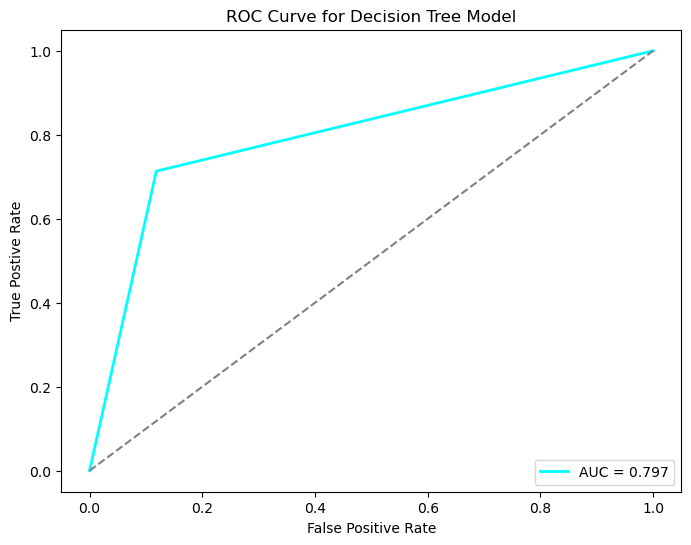

In [46]:
# Plot the AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='aqua', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # reference line of AUC at 0.5
plt.xlabel('False Positive Rate')
plt.ylabel('True Postive Rate')
plt.title('ROC Curve for Decision Tree Model')
plt.legend(loc='lower right')
plt.show()

                       feature  importance
                        Tenure    0.418025
                 MonthlyCharge    0.343777
             Contract_One year    0.088233
             Contract_Two Year    0.072045
   InternetService_Fiber Optic    0.066707
PaymentMethod_Electronic Check    0.003371
                   Gender_Male    0.002466
                      Children    0.001402


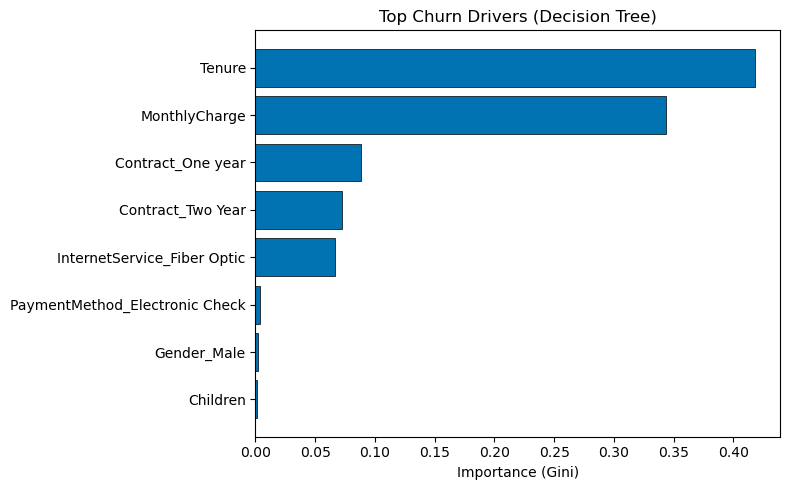

In [96]:
# Update 2026-07-15: feature_importances_ answers "which factors most influence churn"
importance = (pd.DataFrame({'feature': X.columns, 'importance': dt_model.feature_importances_})
              .sort_values('importance', ascending=False).reset_index(drop=True))
print(importance.head(8).to_string(index=False))

top = importance.head(8).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top['feature'], top['importance'], color='#0173b2', edgecolor='black', linewidth=0.5)
plt.xlabel('Importance (Gini)'); plt.title('Top Churn Drivers (Decision Tree)')
plt.tight_layout(); plt.show()

In [102]:
# Update 2026-07-15: expanded evaluation
baseline = max(y_test.mean(), 1 - y_test.mean())
print(f'Accuracy : {accuracy:.3f}  (majority-class baseline {baseline:.3f})')
print(f'AUC      : {auc_score:.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}   <- share of real churners caught')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['No churn', 'Churn']))
print('Confusion matrix [[TN FP][FN TP]]:')
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.837  (baseline 0.735)
AUC      : 0.797
Precision: 0.685
Recall   : 0.713
F1       : 0.699

Confusion matrix [[TN FP][FN TP]]:
[[1296  174]
 [ 152  378]]
